# Test Dataset Construction
### hydrated data viz

# TODOS:
1. display results on map
2. show original text with results
3. build v0.1 of test dataset


In [1]:
import json
import logging
from pathlib import Path

from text2graph.schema import RelationshipTriplet

In [2]:
# !scp -r cosmos0001.chtc:/hdd/imcconnell2/text2graph_llm/text2graph/scripts/output/keeper /Users/imcconnell/PycharmProjects/text2graph_llm/data/hydrated_triplet_dataset/

In [3]:
from text2graph.eval_dataset.data import load_triplets_from_dir


hydrated_json_paths = sorted(list(Path("/Users/imcconnell/PycharmProjects/text2graph_llm/data/hydrated_triplet_dataset/keeper").glob("*.json")))
triplets = load_triplets_from_dir(hydrated_json_paths)

11167 triplets loaded from 6785 files.


In [4]:
triplets[0].provenance.additional_values #['doc_ids'][0]

{'temperature': 0.0,
 'prompt': 'v3',
 'doc_ids': ['620f314aad0e9c819b10a2b3'],
 'triplet_db': {'triplet_db_pk': '1fc4495b-16e3-4226-9da5-f15522b7e306',
  'paragraph_hash': 3,
  'xdd_id': '620f314aad0e9c819b10a2b3'}}

# create table PK to hashed text lookup

In [5]:
from text2graph.eval_dataset.db import DB_ROW_TUPLES_COLUMN_LOOKUP, load_all_rows_from_sqlite_db


db_path = "/Users/imcconnell/PycharmProjects/text2graph_llm/notebooks/data/data_dump_240430.db"
rows = load_all_rows_from_sqlite_db(db_path=db_path)


TABLE_PK_TO_HASHED_TEXT = {
    row[DB_ROW_TUPLES_COLUMN_LOOKUP["table_pk"]]: row[DB_ROW_TUPLES_COLUMN_LOOKUP["hashed_text"]]
    for row in rows
}

# define spatial relationship dataclass and conversion from triplet

In [3]:
import os
import pyproj
import requests
import weaviate
from tqdm.auto import tqdm
from datetime import datetime
from dataclasses import dataclass


from text2graph.eval_dataset.relationships import SpatialRelationship


geod = pyproj.Geod(ellps="WGS84")




# create all spatial relationships and pull original text from VectorDB

In [ ]:

# Takes about half an hour!


In [12]:
# Persist this representation to disk!



# my_sr = spatial_relationships[0]
# my_sr_json_str = json.dumps(dataclasses.asdict(my_sr), indent=2)
# print(my_sr_json_str)
# new_sr = SpatialRelationship(**json.loads(my_sr_json_str))
# print(new_sr)


{
  "subject_name": "El Chocho",
  "subject_lat": 1.4469429,
  "subject_lon": -75.8159827,
  "predicate": "is the location of",
  "object_name": "Segovia Formation",
  "object_lat": 32.623,
  "object_lon": -99.445,
  "doc_id": "620f314aad0e9c819b10a2b3",
  "hashed_text": "a46cf20c1715732228032b059992e5958d9bfc4174c5c775c3d40150074587df",
  "original_paragraph": "SRK Consulting (U.S.), Inc. NI 43-101 Technical Report \u2013 Segovia Prefeasibility Study \u2022 During 2016, the process plant operating cost averaged US$29.51/t processed and was equivalent to US$66.58/Au oz produced. During 2017, the process plant operating cost averaged US$31.88/t processed and was equivalent to 66.71/Au oz produced. During 2018, the process plant operating cost averaged US$28.88/t processed and was equivalent to 58.29/Au oz produced; \u2022 Process plant capital expenditures for 2018 total US$2.94 million for completed projects. The major capital expenditure in 2018 was the installation of the tailings fi

# persist spatial relationships to disk - or load if already persisted

In [6]:
from pathlib import Path
import dataclasses
import json

from text2graph.eval_dataset.relationships import (
    SpatialRelationship, load_all_spatial_relationships, triplet_to_spatial_relationship, dump_all_spatial_relationships
)


# load spatial relationships from disk if they exist, otherwise create them and save them to disk.
output_path = Path("/Users/imcconnell/PycharmProjects/text2graph_llm/data/spatial_relationships.json")
if output_path.exists():
    spatial_relationships = load_all_spatial_relationships(output_path)
else:
    # pull in text from weaviate and create spatial relationships
    spatial_relationships = [
        triplet_to_spatial_relationship(triplet=triplet, table_pk_to_hashed_text_lookup=TABLE_PK_TO_HASHED_TEXT) 
        for triplet in tqdm(triplets)
    ]
    print(len(spatial_relationships))
    dump_all_spatial_relationships(spatial_relationships, output_path)

print(f"total number of loaded spatial relatinships: {len(spatial_relationships)} e.g.")
print(json.dumps(dataclasses.asdict(spatial_relationships[0]), indent=2))

total number of loaded spatial relatinships: 11167
{
  "subject_name": "El Chocho",
  "subject_lat": 1.4469429,
  "subject_lon": -75.8159827,
  "predicate": "is the location of",
  "object_name": "Segovia Formation",
  "object_lat": 32.623,
  "object_lon": -99.445,
  "doc_id": "620f314aad0e9c819b10a2b3",
  "hashed_text": "a46cf20c1715732228032b059992e5958d9bfc4174c5c775c3d40150074587df",
  "original_paragraph": "SRK Consulting (U.S.), Inc. NI 43-101 Technical Report \u2013 Segovia Prefeasibility Study \u2022 During 2016, the process plant operating cost averaged US$29.51/t processed and was equivalent to US$66.58/Au oz produced. During 2017, the process plant operating cost averaged US$31.88/t processed and was equivalent to 66.71/Au oz produced. During 2018, the process plant operating cost averaged US$28.88/t processed and was equivalent to 58.29/Au oz produced; \u2022 Process plant capital expenditures for 2018 total US$2.94 million for completed projects. The major capital expendit

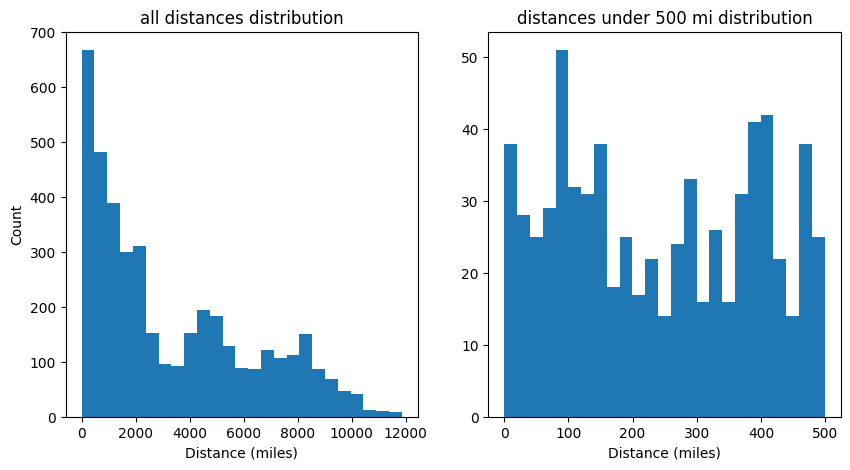

In [42]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
distances = [sr.distance(geod) for sr in spatial_relationships if sr.object_lat is not None and sr.subject_lat is not None]
bin_distance_cutoff_miles = 500
distances_under_cutoff = [d for d in distances if d <= bin_distance_cutoff_miles]
bins = 25
_ = ax[0].hist(
    distances,
    bins=bins,
    label="all distances"
)
ax[0].set_xlabel("Distance (miles)")
ax[0].set_ylabel("Count")
ax[0].set_title("all distances distribution")

_ = ax[1].hist(
    distances_under_cutoff,
    bins=bins,
)
ax[1].set_title(f"distances under {bin_distance_cutoff_miles} mi distribution")
ax[1].set_xlabel("Distance (miles)")
plt.show()

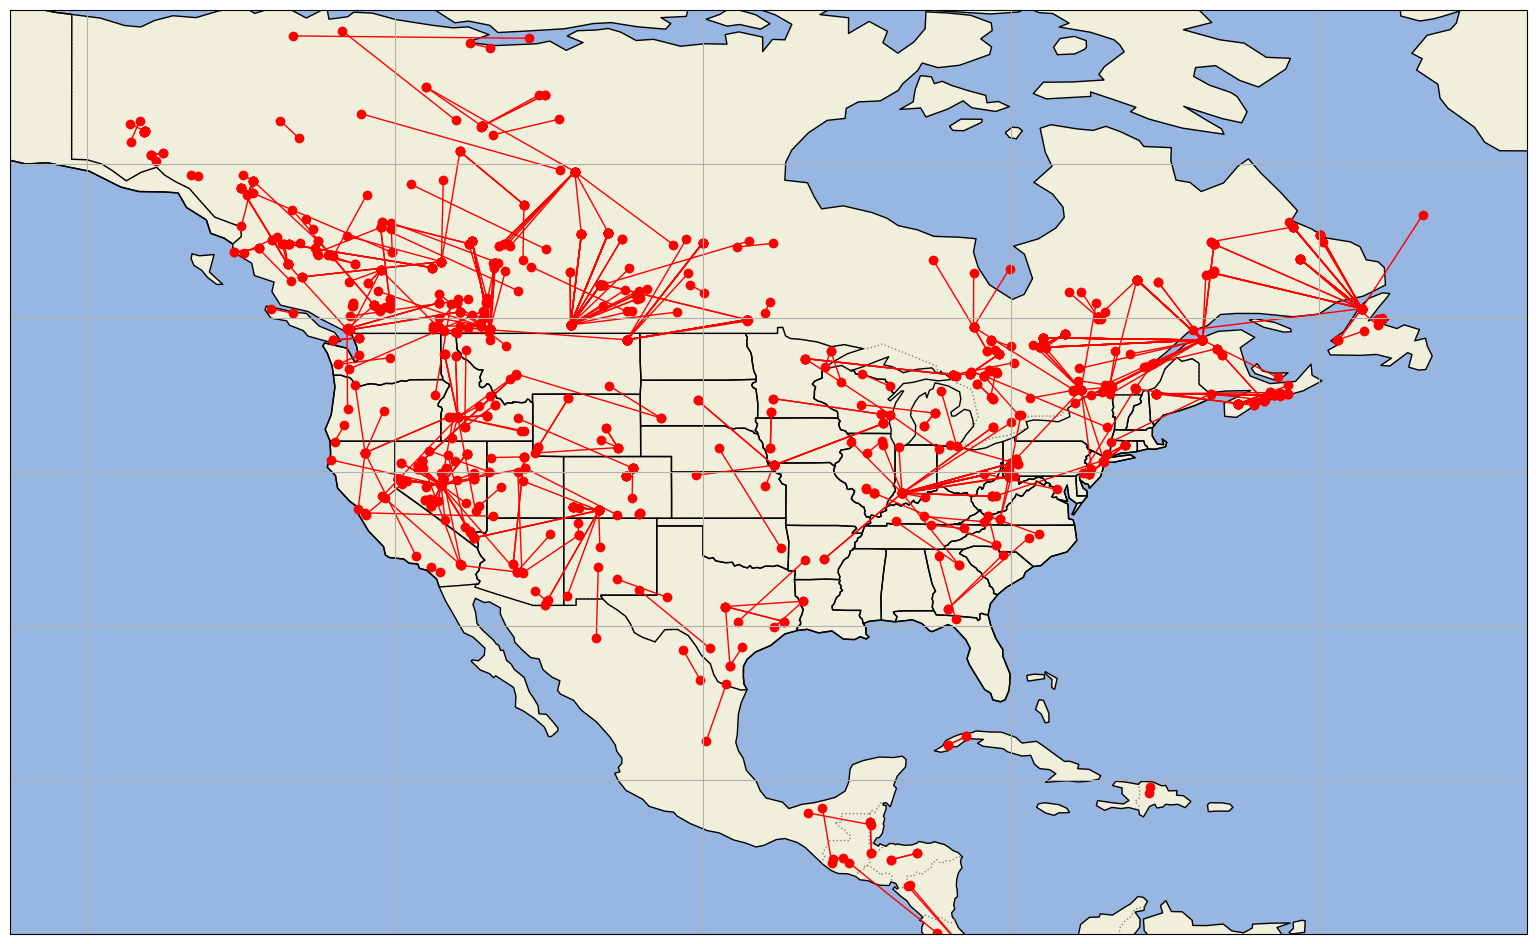

In [7]:
from text2graph.eval_dataset.relationships import plot_spatial_relationships, CONUS_PLUS_EXTENT


plot_spatial_relationships(
    spatial_relationships=spatial_relationships, 
    cutoff_miles=500,
    labels=False,
    plot_extent=CONUS_PLUS_EXTENT
)
plt.show()



# create folium map of relationships

In [146]:
import folium
from text2graph.eval_dataset.plot import bin_spatial_relationships_by_distance, group_from_spatial_relationships


MADISON_WI = (43.0722, -89.4008)
m = folium.Map(location=MADISON_WI, tiles="cartodb positron", zoom_start=5)
binned_srs = bin_spatial_relationships_by_distance(
    spatial_relationships=spatial_relationships, 
    bins=[100, 200, 500, 1000],
    geod=pyproj.Geod(ellps="WGS84")
)
for distance_upper_bound, srs in binned_srs.items():
    print(f"{len(srs)} relationships with distance <= {distance_upper_bound} miles")
    group = group_from_spatial_relationships(spatial_relationships=srs, group_name=f"Distances <= {distance_upper_bound} miles")
    group.add_to(m)

folium.LayerControl().add_to(m)
# m  # uncomment to plot interactive folium map in notebook


171 relationships with distance <= 100 miles
144 relationships with distance <= 200 miles
381 relationships with distance <= 500 miles
489 relationships with distance <= 1000 miles


In [45]:
# dump map to html
m.save("/Users/imcconnell/PycharmProjects/text2graph_llm/notebooks/data/relationship_map.html")

In [373]:
from text2graph.macrostrat import find_all_occurrences

sr_index = 0
sr = spatial_relationships[sr_index]
print(sr.original_paragraph)
print(sr.object_name)
find_all_occurrences(sr.original_paragraph, [sr.object_name])

# for object_to_find in [sr.object_name, ' '.join(sr.object_name.split()[:-1])]:
#         try:
#             object_start = find_all_occurrences(sr.original_paragraph, object_to_find)[0]['start']
#             break
#         except IndexError:
#             object_start = None
    
#     try:
#         predicate_start = find_all_occurrences(sr.original_paragraph, sr.predicate)[0]['start']
#     except IndexError:
#         predicate_start = None
    
#     try:
#         subject_start = find_all_occurrences(sr.original_paragraph, sr.subject_name)[0]['start']
#     except IndexError:
#         subject_start = None

INFO:root:The function 'find_all_occurrences' took 0.0000 seconds to execute.


SRK Consulting (U.S.), Inc. NI 43-101 Technical Report – Segovia Prefeasibility Study • During 2016, the process plant operating cost averaged US$29.51/t processed and was equivalent to US$66.58/Au oz produced. During 2017, the process plant operating cost averaged US$31.88/t processed and was equivalent to 66.71/Au oz produced. During 2018, the process plant operating cost averaged US$28.88/t processed and was equivalent to 58.29/Au oz produced; • Process plant capital expenditures for 2018 total US$2.94 million for completed projects. The major capital expenditure in 2018 was the installation of the tailings filter plant located at El Chocho that cost US$2.16 million; • Planned capital expenditures for 2019 total US$1.71 million with US$202,000 devoted to the metallurgical laboratory; • Tailings is discharged to dehydration cell where the tailings are partially dewatered and then transferred to the final Tailings Storage Facility (TSF) El Chocho: o Slurry tailings are discharged to t

[]

# create dataset

In [252]:
from IPython.display import HTML
from text2graph.eval_dataset.schema import (
    SQuADStratPipelineQuestion, questions_from_spatial_relationships, render_question_to_html_eval_format, 
    new_question_from_old, serialize_questions_to_json_by_index, BURGUNDY, BLUE, MINT, RASPBERRY, ORANGE, LIGHT_GREY, DARK_GREY
)




In [9]:
print(f"{len(spatial_relationships)=}")

len(spatial_relationships)=11167


## Create SQuAD questions from spatial relationships

In [64]:
print(f"{len(spatial_relationships)=}")
questions = questions_from_spatial_relationships(spatial_relationships=spatial_relationships)
sorted_by_distance = sorted([x for x in questions if x.distance_in_miles], key=lambda x: x.distance_in_miles)
putative_squad_question = (x for x in sorted_by_distance)
print(f"{len(sorted_by_distance)=}")
counter = 0

len(spatial_relationships)=11167
Failed distance for Sample Formation - placed - pre-numbered plastic sample with error: input must be a scalar
Failed distance for Stone Formation - have diamond abundances - 2003 coreholes located in the 122 south crater (MPK-S and OPK areas) with error: input must be a scalar
Failed distance for Stone Formation - have stone abundances - coreholes 122-05 and 122-06, and an additional 252 kg of chip samples from large diameter reverse circulation drillholes 122-07 and 122-08 with error: input must be a scalar
Failed distance for Stone Formation - have stone abundances - 2003 coreholes in the 122 south crater (MPK-S and OPK-S1 areas) with error: input must be a scalar
Failed distance for Sample Formation - stored_in - secure sample storage area with error: input must be a scalar
Failed distance for Sample Formation - taken_to - Midway Gold geological contractors with error: input must be a scalar
Failed distance for Sample Formation - duplicate samples w

index=0



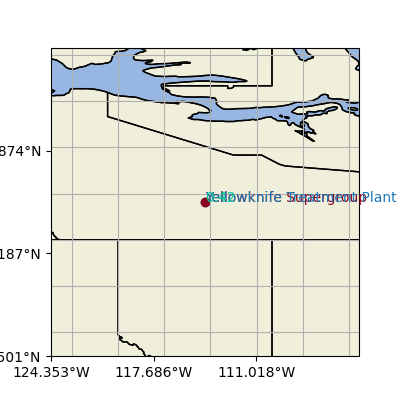

In [11]:
q = next(putative_squad_question)
print(f"index={counter}")
counter += 1
HTML(q.html_format())


In [36]:
keepers = [20, 92, 96, 97, 194, 234, 285, ]
maybe_keeper = [57, 59, 63, 250]
implied_formation_right = []
formation_or_group_is_actually_a_mine = [
    11, 12, 13, 23, 26, 28, 33, 34, 58, 123, 131, 132, 144, 145, 151, 152, 153, 154, 155, 172, 173, 177, 191, 192, 229, 230, 273, 275, 281, 287,

]
formation_or_group_is_actually_another_entity = [
    51, 52, 61, 62, 65, 68, 75, 82, 130, 139, 140, 146, 180, 207, 210, 224, 225, 272, 286, 295, 296, 299, 300
]
implied_formation_wrong = [
    0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 14, 15, 18, 19 ,21, 22, 23, 24, 25, 27, 29, 30, 31, 32, 35, 36, 37, 38, 39, 40, 43, 44, 45, 46, 47, 48, 
    49, 50, 53, 54, 56, 60, 66, 67, 69, 70, 71, 72, 74, 76, 77, 78, 79, 80, 81, 83, 84, 85, 87, 90, 91, 95, 98, 99, 100, 101, 
    102, 103, 104, 105, 106, 108, 109, 110, 113, 114, 115, 116, 117, 118, 119, 120, 121, 124, 125, 126, 127, 128, 129, 133, 134, 135,
    136, 137, 138, 142, 143, 147, 148, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 167, 168, 169, 170, 171, 174, 175, 178, 181,
    182, 183, 184, 185, 186, 188, 193, 195, 196, 197, 198, 199, 200, 201, 204, 205, 206, 208, 209, 211, 212, 213, 214, 216, 217,
    218, 219, 220, 221, 222, 223, 227, 228, 231, 232, 233, 235, 236, 238, 239, 240, 241, 242, 243, 244, 245, 246, 247, 248, 249, 
    251, 252, 253, 254, 255, 256, 257, 258, 259, 260, 261, 262, 263, 264, 265, 266, 267, 268, 269, 270, 271, 272, 274, 276, 277,
    278, 279, 280, 282, 283, 289, 301, 302, 305, 306, 307, 308, 309, 
]
crud = [
    16, 17, 41, 42, 55, 64, 73, 86, 88, 89, 93, 94, 107, 111, 122, 141, 166, 176, 179, 189, 190, 202, 203, 215, 226, 237, 284, 288, 290,
    291, 292, 293, 294, 298, 303, 304, 310, 311,
]
non_english = [297, ]

Generally implying Formation or Group is VERY non-precise. Nevada is particular for this dataset is frequently mis-identified as the Nevada Formation.


In [ ]:
# Serialize keepers to json

serialize_questions_to_json_by_index(
    questions=sorted_by_distance, 
    output_path=Path("/Users/imcconnell/PycharmProjects/text2graph_llm/data/squad_question_keepers.json"), 
    indexes=keepers
)


## get negative examples for dataset - no stratname, or no location, or neither

In [ ]:
# negative examples list
updated_new_negative_example_qs = []

In [112]:
# create negative example generator
negative_examples = [
    x 
    for i, x in enumerate(sorted_by_distance) 
    if i in formation_or_group_is_actually_a_mine + formation_or_group_is_actually_another_entity + implied_formation_wrong + crud
]
negative_example_gen = (x for x in negative_examples)
negative_example_counter = 0


index=75



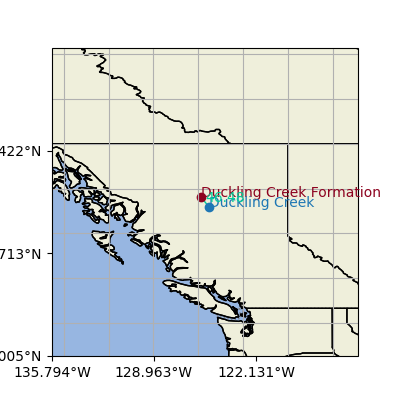

In [251]:
# next negative example
negative_example = next(negative_example_gen)
print(f"index={negative_example_counter}")
negative_example_counter += 1
HTML(negative_example.html_format())

In [245]:
new_negative_example_q = new_question_from_old(
    question=negative_example,
    **dict(
        object=None,
        predicate=None,
        # subject=None
        # subject="Restigouche County in the Canadian province of New Brunswick",
    )

)
HTML(new_negative_example_q.html_format())

In [246]:
# add to list of updated negative examples
updated_new_negative_example_qs.append(new_negative_example_q)
print(f"{len(updated_new_negative_example_qs)=}")

len(updated_new_negative_example_qs)=36


In [220]:
# last added
HTML(updated_new_negative_example_qs[-1].html_format())

In [253]:
serialize_questions_to_json_by_index(
    questions=updated_new_negative_example_qs,
    output_path=Path("/Users/imcconnell/PycharmProjects/text2graph_llm/notebooks/data/negative_examples.json"),
    indexes=list(range(len(updated_new_negative_example_qs)))
)

In [ ]:
# indexes in negative_examples list
actually_good_ones = [22, 63]

INFO:root:The function 'find_all_occurrences' took 0.0840 seconds to execute.



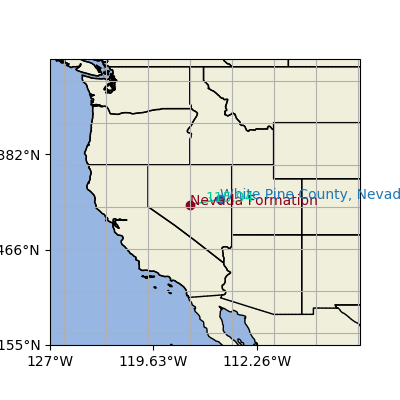

In [541]:
HTML(render_question_to_html_eval_format(sorted_by_distance[187]))

INFO:root:The function 'find_all_occurrences' took 0.0207 seconds to execute.



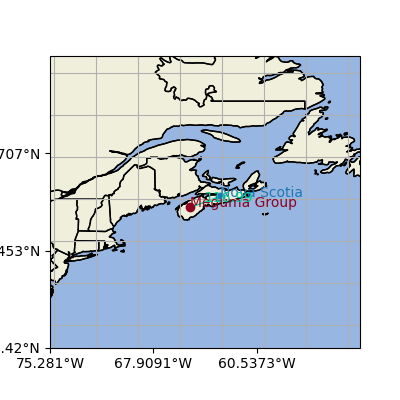

In [245]:
# sometimes coincidental that an informal stratname is also a mine name:
HTML(render_question_to_html_eval_format(sorted_by_distance[191]))

INFO:root:The function 'find_all_occurrences' took 0.0211 seconds to execute.



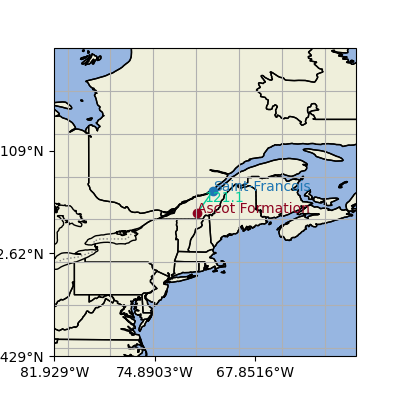

In [246]:
# sometimes coincidental that an informal stratname is also a different entity:
HTML(render_question_to_html_eval_format(sorted_by_distance[207]))

INFO:root:The function 'find_all_occurrences' took 0.0311 seconds to execute.



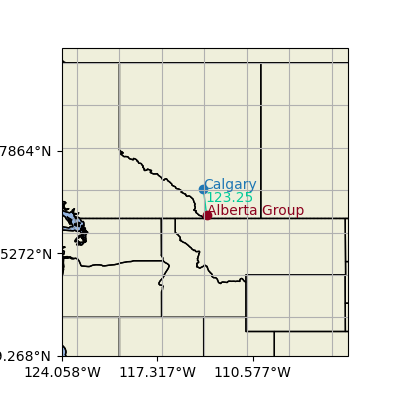

In [247]:
# extractions from paragraphs that are nothing to do with stratigraphic names:
HTML(render_question_to_html_eval_format(sorted_by_distance[215]))

INFO:root:The function 'find_all_occurrences' took 0.0255 seconds to execute.



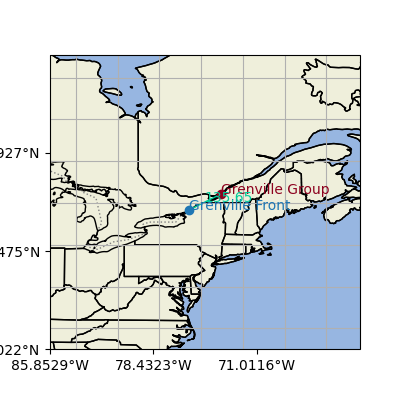

In [248]:
# some extractions wehre the stratname and location overlap the same tokens:
HTML(render_question_to_html_eval_format(sorted_by_distance[231]))

INFO:root:The function 'find_all_occurrences' took 0.0191 seconds to execute.



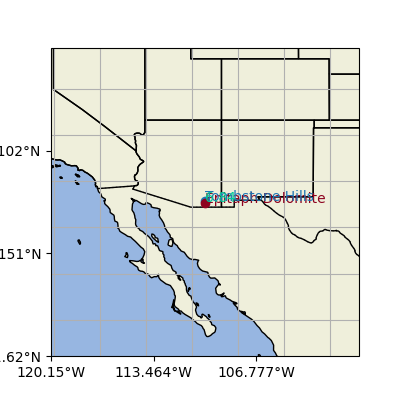

In [249]:
# Very few keepers - actual stratname location extractions that are close by.
# actually missed the true streatigraphic name, and found the informal ones!
HTML(render_question_to_html_eval_format(sorted_by_distance[20]))

INFO:root:The function 'find_all_occurrences' took 0.0258 seconds to execute.



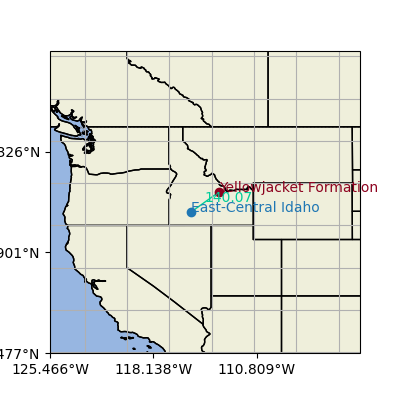

In [250]:
# some keepers appear to be references:
HTML(render_question_to_html_eval_format(sorted_by_distance[234]))

INFO:root:The function 'find_all_occurrences' took 0.0233 seconds to execute.



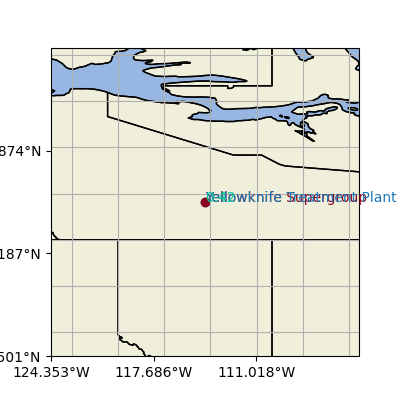

In [251]:
HTML(render_question_to_html_eval_format(sorted_by_distance[0]))

INFO:root:The function 'find_all_occurrences' took 0.0214 seconds to execute.



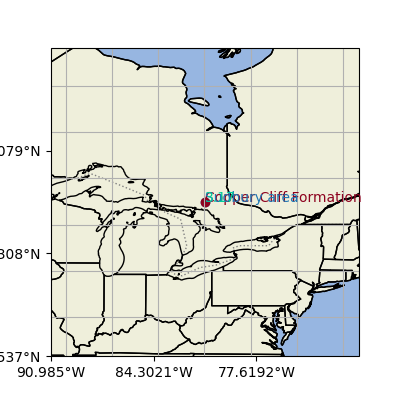

In [252]:
formation_or_group_is_actually_a_mine = [
    11, 12, 13, 23, 26, 28, 33, 34, 58, 123, 131, 132, 144, 145, 151, 152, 153, 154, 155, 172, 173, 177, 191, 192, 229, 230, 273, 275, 281, 287,

]
HTML(render_question_to_html_eval_format(sorted_by_distance[11]))

In [542]:
sorted_by_distance[keepers[0]].model_dump()

{'context': 'Permian Epitaph Dolomite (Ped) The Epitaph is composed of dolomite, sandstone and limestone and is 780 feet thick in the\nTombstone Hills. The lower part of the Epitaph is resistant and is probably what is exposed in the Redrock Canyon area. The upper part is sandy and shaly and was probably eroded and overlain by the Cretaceous Glance conglomerate. It is exposed on the north and south sides of the East Branch of Redrock Canyon, and on the north tip of Airfield Ridge both within the Redrock Canyon project area.\nBecause of the impermeability of the lower Epitaph, it is probably not a good horizon for mineral concentration.',
 'object': 'Epitaph Dolomite',
 'object_start': 8,
 'predicate': 'composed of',
 'predicate_start': 46,
 'subject': 'Tombstone Hills',
 'subject_start': 121,
 'context_docid': '620f06e9ad0e9c819b0ffba1',
 'context_hashed_text': 'd900031b5e05743fcb880b8dac3f066471232d134b82a589a48d72a92b209e48',
 'question': None,
 'distance_in_miles': 6.835201697365409

# get all paragraphs in a doucment on weaviate

In [431]:

# client = get_weaviate_client()
# where_filter = {
#     "path": ["paper_id"],
#     "operator": "Equal",
#     "valueText": sorted_by_distance[20].context_docid,
# }
# response = (
#     client.query.get("Paragraph", ["text_content"])
#     .with_where(where_filter)
#     .do()
# )
# [ x['text_content'] for x in response["data"]["Get"]["Paragraph"]]

/usr/local/anaconda3/envs/usgs2023/lib/python3.11/site-packages/weaviate/warnings.py:158: DeprecationWarning: Dep016: You are using the Weaviate v3 client, which is deprecated.
            Consider upgrading to the new and improved v4 client instead!
            See here for usage: https://weaviate.io/developers/weaviate/client-libraries/python
            
  warnings.warn(


['Prepared by: Jonathan DuHamel, M.Sc., Consulting Geologist, Registered Geologist #19194, Arizona Qualified Person per NI 43-101 and by\nMineral Regulations of Land Belonging to the State of Arizona and the Title Held by JABA to the Redrock Canyon Project Area\nThe Redrock Canyon Project, is owned 100% by Consolidated JABA Inc., a TSXV listed company through its wholly owned US Subsidiary JABA (US) Inc. (hereinafter - JABA). All costs in this report are stated in US Dollars.\nGeologic evidence to date suggests that Redrock canyon is part of the gold halo surrounding the buried Hay Mountain porphyry copper system which in turn is related to the very large Tombstone Caldera complex of Laramide age (72 - 63 million years ago). Because of its environment and being situated in receptive Paleozoic sedimentary rocks it has potential for a very large body of mineralized rock. Redrock manifests alteration and mineralization characteristics of Carlin Style deposits including sub-micron gold. Po

In [442]:
# import requests


# def strat_names_in_docid(docid: str) -> list[str]:
#     """
#     Get all informal strat names in a docid.
#     """
#     # url = f"https://xdd.wisc.edu/api/articles?docid={docid}&full_results=true&known_terms=stratigraphic_names"
#     url = f"https://xdd.wisc.edu/api/articles?dataset=Geoarchive&full_results=true&known_terms=stratigraphic_names"
#     response = requests.get(url)
#     response.raise_for_status()
#     response_json = response.json()
#     print(json.dumps(response_json, indent=2))
#     stratnames = response_json["success"]["data"][0]["known_terms"][0]["stratigraphic_names"]

#     return stratnames

# sns = strat_names_in_docid(sorted_by_distance[20].context_docid)
# sns

{
  "success": {
    "v": 2,
    "data": [
      {
        "type": "fulltext",
        "_gddid": "661a9bbb1a703effc6ab12b4",
        "title": "NI 43-101 Technical Report for the Sandtown Project in Arkansas, United States dated March 2016",
        "volume": "",
        "journal": "",
        "link": [
          {
            "url": "https://geokb.wikibase.cloud/entity/Q27965",
            "type": "publisher"
          }
        ],
        "publisher": "Canadian Securities Administrators",
        "abstract": "",
        "author": [],
        "pages": "",
        "number": "",
        "known_terms": [
          {
            "stratigraphic_names": [
              "St Peter Sandstone",
              "Everton Formation",
              "Memphis Sand"
            ]
          }
        ],
        "identifier": [],
        "_score": null
      },
      {
        "type": "fulltext",
        "_gddid": "661a9bbb1a703effc6ab12ad",
        "title": "NI 43-101 Technical Report for the Simon Projec

['St Peter Sandstone', 'Everton Formation', 'Memphis Sand']

In [366]:
import json
import httpx
import logging
from pathlib import Path
from rich.progress import Progress
from tenacity import retry, stop_after_attempt, wait_exponential, RetryError


logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)
XDD_V1_BASE_URL = "https://xdd.wisc.edu/api/v1/"


@retry(
    stop=stop_after_attempt(5), 
    wait=wait_exponential(multiplier=1, min=4, max=10)
)
def get_api_response(client, url):
    r = client.get(url)
    r.raise_for_status()
    return r.json()


def all_strat_names_in_all_docids_for_dataset(dataset: str) -> dict[str, list[str]]:
    """
    Get all informal strat names in a docid.
    """
    route = "/articles" 
    params = {
        "dataset": dataset, 
        "full_results": "true", 
        "known_terms": "stratigraphic_names",
        "known_entities": "stratname_candidates",
    }
    param_str = '&'.join([f"{k}={v}" for k, v in params.items()])
    url = f"{XDD_V1_BASE_URL}{route}?{param_str}"
    strat_names = {}
    transport = httpx.HTTPTransport(retries=1)
    timeout_seconds = 30
    with httpx.Client(timeout=timeout_seconds, transport=transport) as client:
        with Progress() as progress:
            response_json = get_api_response(client, url)
            expected_article_count = response_json["success"]["hits"]
            get_paginated_stratnames = progress.add_task(
                "get_paginated_stratnames", 
                total=expected_article_count
            )
            counter = 1            
            while url:
                for doc in response_json["success"]["data"]:
                    counter += 1
                    progress.update(get_paginated_stratnames, advance=1)
                    docid = doc["_gddid"]
                    strat_names[docid] = {}
                    try:
                        strat_names[docid]["stratnames"] = doc["known_terms"][0]["stratigraphic_names"]
                    except (KeyError, IndexError):
                        strat_names[docid]["stratnames"] = []

                    try:
                        strat_names[docid]["stratname_candidates"] = doc["known_entities"]["stratname_candidates"][0]["candidates"]
                    except (KeyError, IndexError):
                        strat_names[docid]["stratname_candidates"] = []
                try:
                    url = response_json["success"]["next_page"]
                    if url:
                        response_json = get_api_response(client, url)
                    else:
                        url = None
                except (KeyError, httpx.UnsupportedProtocol, RetryError) as e:
                    if not isinstance(e, KeyError):  # expect next_page missing and KeyError at last page of API results
                        logger.warning(f"Error fetching xdd article strat_names {url=}\n{e}")
                    url = None

    if counter < expected_article_count:
        logger.warning(f"Expected {expected_article_count} articles, but only got {counter}")
    return strat_names


def get_cached_strat_names_for_dataset(
    dataset: str, 
    datafolder: Path | None = None, 
    clobber: bool = False
) -> dict[str, list[str]]:
    """
    Get all informal strat names in a docid.
    """
    if not datafolder:
        datafolder = Path("/Users/imcconnell/PycharmProjects/text2graph_llm/data")
    
    datafolder.mkdir(exist_ok=True, parents=True)
    
    datapath = datafolder / f"{dataset}_strat_names.json"
    if datapath.exists() and not clobber:
        with open(datapath, 'r') as f:
            return json.load(f)
    
    strat_names = all_strat_names_in_all_docids_for_dataset(dataset=dataset)
    total_docids = len(strat_names)
    total_extracted_stratnames_and_candidates = sum([len(v["stratnames"]) + len(v["stratname_candidates"]) for v in strat_names.values()])
    print(f"extracted {total_extracted_stratnames_and_candidates} stratnames and candidates from {total_docids} docids")
    with open(datapath, 'w') as f:
        json.dump(strat_names, f)
    
    return strat_names


all_strat_names_in_geoarchive = get_cached_strat_names_for_dataset("Geoarchive", clobber=False)
keys = list(all_strat_names_in_geoarchive.keys())
[(key, all_strat_names_in_geoarchive[key]) for key in keys[0]]

Output()

INFO:httpx:HTTP Request: GET https://xdd.wisc.edu/api/v1//articles?dataset=Geoarchive&full_results=true&known_terms=stratigraphic_names&known_entities=stratname_candidates "HTTP/1.1 200 OK"


INFO:httpx:HTTP Request: GET https://xdd.wisc.edu/api/v1//articles?scroll_id=0e752d7e-1592-4ddb-9acb-4f3c34f5940d&known_terms=stratigraphic_names&known_entities=stratname_candidates "HTTP/1.1 200 OK"


INFO:httpx:HTTP Request: GET https://xdd.wisc.edu/api/v1//articles?scroll_id=0e752d7e-1592-4ddb-9acb-4f3c34f5940d&known_terms=stratigraphic_names&known_entities=stratname_candidates "HTTP/1.1 200 OK"


INFO:httpx:HTTP Request: GET https://xdd.wisc.edu/api/v1//articles?scroll_id=0e752d7e-1592-4ddb-9acb-4f3c34f5940d&known_terms=stratigraphic_names&known_entities=stratname_candidates "HTTP/1.1 200 OK"


...

INFO:httpx:HTTP Request: GET https://xdd.wisc.edu/api/v1//articles?scroll_id=0e752d7e-1592-4ddb-9acb-4f3c34f5940d&known_terms=stratigraphic_names&known_entities=stratname_candidates "HTTP/1.1 200 OK"


INFO:httpx:HTTP Request: GET https://xdd.wisc.edu/api/v1//articles?scroll_id=0e752d7e-1592-4ddb-9acb-4f3c34f5940d&known_terms=stratigraphic_names&known_entities=stratname_candidates "HTTP/1.1 200 OK"


INFO:httpx:HTTP Request: GET https://xdd.wisc.edu/api/v1//articles?scroll_id=0e752d7e-1592-4ddb-9acb-4f3c34f5940d&known_terms=stratigraphic_names&known_entities=stratname_candidates "HTTP/1.1 200 OK"


extracted 120934 stratnames and candidates from 14336 docids


[('6206b263ad0e9c819bf0ec3f',
  {'stratnames': ['Ecca Group', 'Dwyka Group', 'Karoo Supergroup'],
   'stratname_candidates': ['Washed Coal Coal',
    'BP Coal',
    'Ecca Formation',
    'Mmamabula Formation',
    'Coal Division',
    'Kalahari Supergroup',
    'Mapashalela Formation',
    'Ecca Subgroup',
    'Vancouver Suite',
    'Dibete Formation',
    'Dwyka Group',
    'Raw Coal',
    'Moderately Complex',
    'Ecca Group',
    'Karoo Supergroup']}),
 ('6206b263ad0e9c819bf0ec67',
  {'stratnames': ['Nosib Group', 'Karoo Supergroup'],
   'stratname_candidates': ['Waterberg Group',
    'Ngkwako Pan Formation',
    'Description Sedimentary Structures Environment Kalahari Group',
    'Ghanzi Group',
    'Nosib Group',
    'Eskadron Formation',
    'Palapye Group',
    'Ghanzi Formation',
    'Otse Group',
    'Kgwebe Formation',
    'Kalahari Group',
    'Roan Supergroup',
    'Karoo Supergroup',
    'Molopo Farms Complex',
    'Kar Formation',
    'Bushveld Complex',
    'Transvaal S

In [367]:
def merge_strat_names_and_candidates(d: dict[str, dict[str, list[str]]]) -> dict[str, list[str]]:
    merged = {}
    for docid, stratname_dict in d.items():
        stratnames = stratname_dict.get("stratnames", [])
        candidates = stratname_dict.get("stratname_candidates", [])
        merged[docid] = stratnames + candidates
    return merged

merged_stratnames = merge_strat_names_and_candidates(all_strat_names_in_geoarchive)
print(f"total processed docids in dataset: {len(merged_stratnames.keys())}")
merged_stratnames_clean = {k: v for k, v in merged_stratnames.items() if v}
print(f"total processed docids with stratnames {len(merged_stratnames_clean.keys())}")
keys = list(merged_stratnames_clean.keys())
[(key, merged_stratnames[key]) for key in keys[:5]]

total processed docids in dataset: 14336
total processed docids with stratnames 11556


[('6206b263ad0e9c819bf0ec3f',
  ['Ecca Group',
   'Dwyka Group',
   'Karoo Supergroup',
   'Washed Coal Coal',
   'BP Coal',
   'Ecca Formation',
   'Mmamabula Formation',
   'Coal Division',
   'Kalahari Supergroup',
   'Mapashalela Formation',
   'Ecca Subgroup',
   'Vancouver Suite',
   'Dibete Formation',
   'Dwyka Group',
   'Raw Coal',
   'Moderately Complex',
   'Ecca Group',
   'Karoo Supergroup']),
 ('6206b263ad0e9c819bf0ec67',
  ['Nosib Group',
   'Karoo Supergroup',
   'Waterberg Group',
   'Ngkwako Pan Formation',
   'Description Sedimentary Structures Environment Kalahari Group',
   'Ghanzi Group',
   'Nosib Group',
   'Eskadron Formation',
   'Palapye Group',
   'Ghanzi Formation',
   'Otse Group',
   'Kgwebe Formation',
   'Kalahari Group',
   'Roan Supergroup',
   'Karoo Supergroup',
   'Molopo Farms Complex',
   'Kar Formation',
   'Bushveld Complex',
   'Transvaal Supergroup',
   'Katanga Supergroup',
   'Mamuno Formation',
   'Calcrete Karoo Supergroup',
   'Nchanga 

In [368]:
def informal_strat_names(stratname: str) -> list[str]:
    """
    Extract informal strat names from a string.
    :param stratname: A stratigraphic name.
    :return: A list of informal strat names.
    """
    strat_words = stratname.split()[:-1]
    strat_words_count = len(strat_words)
    return [' '.join(strat_words[strat_words_count-x:]) for x in range(1, strat_words_count+1)]


def add_informal_strat_names(doc_id_strat_names_dct: dict[str, list[str]]) -> list[str]:
    """
    Get all informal strat names in a docid.
    """
    lol_informal_strat_names_dct = {
        docid: [informal_strat_names(stratname) for stratname in strat_names] for docid, strat_names in doc_id_strat_names_dct.items()
    }
    return {docid: doc_id_strat_names_dct[docid] + [y for x in lol for y in x]  for docid, lol in lol_informal_strat_names_dct.items()}



informal_strat_names("Petrified Forest Member")
# add_informal_strat_names(all_strat_names_in_geoarchive)
merged_strat_names_clean_with_informal = add_informal_strat_names(merged_stratnames_clean)
keys = list(merged_strat_names_clean_with_informal.keys())
print(f"docid={keys[0]}")
example = merged_strat_names_clean_with_informal[keys[0]]
top = list(range(10))
tail = list(range(len(example)-10, len(example)))
[(key, example[key]) for key in top + tail]


docid=6206b263ad0e9c819bf0ec3f


[(0, 'Ecca Group'),
 (1, 'Dwyka Group'),
 (2, 'Karoo Supergroup'),
 (3, 'Washed Coal Coal'),
 (4, 'BP Coal'),
 (5, 'Ecca Formation'),
 (6, 'Mmamabula Formation'),
 (7, 'Coal Division'),
 (8, 'Kalahari Supergroup'),
 (9, 'Mapashalela Formation'),
 (27, 'Kalahari'),
 (28, 'Mapashalela'),
 (29, 'Ecca'),
 (30, 'Vancouver'),
 (31, 'Dibete'),
 (32, 'Dwyka'),
 (33, 'Raw'),
 (34, 'Moderately'),
 (35, 'Ecca'),
 (36, 'Karoo')]

# filter spatial relationships by allowed informal strat names

INFO:root:The function 'find_all_occurrences' took 0.0000 seconds to execute.
INFO:root:The function 'find_all_occurrences' took 0.0001 seconds to execute.
INFO:root:The function 'find_all_occurrences' took 0.0000 seconds to execute.
INFO:root:The function 'find_all_occurrences' took 0.0000 seconds to execute.
INFO:root:The function 'find_all_occurrences' took 0.0000 seconds to execute.
INFO:root:The function 'find_all_occurrences' took 0.0001 seconds to execute.
INFO:root:The function 'find_all_occurrences' took 0.0000 seconds to execute.
INFO:root:The function 'find_all_occurrences' took 0.0002 seconds to execute.
INFO:root:The function 'find_all_occurrences' took 0.0000 seconds to execute.
INFO:root:The function 'find_all_occurrences' took 0.0001 seconds to execute.
INFO:root:The function 'find_all_occurrences' took 0.0000 seconds to execute.
INFO:root:The function 'find_all_occurrences' took 0.0002 seconds to execute.
INFO:root:The function 'find_all_occurrences' took 0.0000 second

len(filtered_spatial_relationships)=937
Failed distance for Athabasca Formation - near - Lake Athabasca to Tazin Lake area with error: input must be a scalar
Failed distance for Athabasca Formation - part_of - Milliken Lake to Fish Hook Point with error: input must be a scalar
Failed distance for Slocan Group - changes trend - enclosing sedimentary rocks with error: input must be a scalar
Failed distance for Smithers Formation - supported_by - exploration programs with error: input must be a scalar
Failed distance for Cobalt Group - correlation - Silverside Property with error: input must be a scalar
Failed distance for Elliot Lake Group - is located in - core storage facility with error: input must be a scalar
Failed distance for Yellowknife Supergroup - Report on 2018 Summer Exploration Program by - Yellowknife City Gold Project with error: input must be a scalar
Failed distance for Takla Group - includes - two main classifications of ore mineralization with error: input must be a sc

INFO:root:The function 'find_all_occurrences' took 0.0000 seconds to execute.
INFO:root:The function 'find_all_occurrences' took 0.0001 seconds to execute.
INFO:root:The function 'find_all_occurrences' took 0.0002 seconds to execute.
INFO:root:The function 'find_all_occurrences' took 0.0001 seconds to execute.
INFO:root:The function 'find_all_occurrences' took 0.0000 seconds to execute.
INFO:root:The function 'find_all_occurrences' took 0.0000 seconds to execute.
INFO:root:The function 'find_all_occurrences' took 0.0000 seconds to execute.
INFO:root:The function 'find_all_occurrences' took 0.0001 seconds to execute.
INFO:root:The function 'find_all_occurrences' took 0.0000 seconds to execute.
INFO:root:The function 'find_all_occurrences' took 0.0001 seconds to execute.
INFO:root:The function 'find_all_occurrences' took 0.0000 seconds to execute.
INFO:root:The function 'find_all_occurrences' took 0.0002 seconds to execute.
INFO:root:The function 'find_all_occurrences' took 0.0000 second

Failed distance for Pioneer Formation - small-scale production began - area of the Pioneer mine with error: input must be a scalar
Failed distance for Pioneer Formation - used an arrastra to treat the ore - area of the Pioneer mine with error: input must be a scalar
Failed distance for Kutcho Formation - is a deposit of - Kutcho Main Deposit with error: input must be a scalar
Failed distance for Kamloops Group - located 60 kilometers southwest of - Guichon Batholith with error: input must be a scalar
Failed distance for Shingle Pass Tuff - caps - several hilltops and plateaus in the caldera with error: input must be a scalar
Failed distance for Pioneer Formation - has as contributing factor - Bralorne-Pioneer gold deposit with error: input must be a scalar
Failed distance for Sokoman Formation - targeted by exploration team - Sokoman Formation with error: input must be a scalar
Failed distance for Sokoman Formation - lowest member in the Sokoman formation stratigraphy column - Lower Ir

INFO:root:The function 'find_all_occurrences' took 0.0000 seconds to execute.
INFO:root:The function 'find_all_occurrences' took 0.0000 seconds to execute.
INFO:root:The function 'find_all_occurrences' took 0.0000 seconds to execute.
INFO:root:The function 'find_all_occurrences' took 0.0000 seconds to execute.
INFO:root:The function 'find_all_occurrences' took 0.0000 seconds to execute.
INFO:root:The function 'find_all_occurrences' took 0.0000 seconds to execute.
INFO:root:The function 'find_all_occurrences' took 0.0000 seconds to execute.
INFO:root:The function 'find_all_occurrences' took 0.0000 seconds to execute.
INFO:root:The function 'find_all_occurrences' took 0.0000 seconds to execute.
INFO:root:The function 'find_all_occurrences' took 0.0000 seconds to execute.
INFO:root:The function 'find_all_occurrences' took 0.0000 seconds to execute.
INFO:root:The function 'find_all_occurrences' took 0.0000 seconds to execute.
INFO:root:The function 'find_all_occurrences' took 0.0001 second

...

Failed distance for Cariboo Group - map of Crown-granted mineral claims on - Cariboo Gold Project with error: input must be a scalar
Failed distance for Cariboo Group - historical geological plan of - 1500 level and longitudinal section, Cariboo Gold Quartz Mine with error: input must be a scalar
Failed distance for Elliot Lake Group - new mine infrastructure development would be in - brownfields areas already disturbed by industrial and mining activity with error: input must be a scalar
Failed distance for Elliot Lake Group - is in place or close at hand - water, electrical, transportation and communications infrastructure with error: input must be a scalar
Failed distance for Karmutsen Formation - notably include - Northeast of Scrutor property with error: input must be a scalar
Failed distance for Meguma Group - has - Caribou Property with error: input must be a scalar
Failed distance for Kettle River Formation - owned by - hundreds of individual lots with error: input must be a sca

INFO:root:The function 'find_all_occurrences' took 0.0000 seconds to execute.
INFO:root:The function 'find_all_occurrences' took 0.0001 seconds to execute.
INFO:root:The function 'find_all_occurrences' took 0.0001 seconds to execute.
INFO:root:The function 'find_all_occurrences' took 0.0000 seconds to execute.
INFO:root:The function 'find_all_occurrences' took 0.0001 seconds to execute.
INFO:root:The function 'find_all_occurrences' took 0.0001 seconds to execute.
INFO:root:The function 'find_all_occurrences' took 0.0000 seconds to execute.
INFO:root:The function 'find_all_occurrences' took 0.0001 seconds to execute.
INFO:root:The function 'find_all_occurrences' took 0.0000 seconds to execute.
INFO:root:The function 'find_all_occurrences' took 0.0000 seconds to execute.
INFO:root:The function 'find_all_occurrences' took 0.0000 seconds to execute.
INFO:root:The function 'find_all_occurrences' took 0.0001 seconds to execute.
INFO:root:The function 'find_all_occurrences' took 0.0001 second

Failed distance for Callville Limestone - has basement rocks - Mt. Baldy Mining District with error: input must be a scalar
Failed distance for Queantoweap Sandstone - has basement rocks - Mt. Baldy Mining District with error: input must be a scalar
Failed distance for Bullion Canyon Volcanics - is disconformably overlain by - Mt. Baldy Mining District with error: input must be a scalar
Failed distance for Carmacks Group - co-author of a technical report - Carmacks Copper Project with error: input must be a scalar
Failed distance for Carmacks Group - co-author of a technical report - Carmacks Copper Deposit with error: input must be a scalar
Failed distance for Carmacks Group - author of a technical report and mineral resource estimate - Carmacks property with error: input must be a scalar
Failed distance for Tonto Group - Phase III work report was dated - Tonto Portion with error: input must be a scalar
Failed distance for Bullion Canyon Volcanics - located in - Big Sugar prospect wit

INFO:root:The function 'find_all_occurrences' took 0.0002 seconds to execute.
INFO:root:The function 'find_all_occurrences' took 0.0000 seconds to execute.
INFO:root:The function 'find_all_occurrences' took 0.0001 seconds to execute.
INFO:root:The function 'find_all_occurrences' took 0.0000 seconds to execute.
INFO:root:The function 'find_all_occurrences' took 0.0001 seconds to execute.
INFO:root:The function 'find_all_occurrences' took 0.0000 seconds to execute.
INFO:root:The function 'find_all_occurrences' took 0.0001 seconds to execute.
INFO:root:The function 'find_all_occurrences' took 0.0000 seconds to execute.
INFO:root:The function 'find_all_occurrences' took 0.0000 seconds to execute.
INFO:root:The function 'find_all_occurrences' took 0.0000 seconds to execute.
INFO:root:The function 'find_all_occurrences' took 0.0000 seconds to execute.
INFO:root:The function 'find_all_occurrences' took 0.0000 seconds to execute.
INFO:root:The function 'find_all_occurrences' took 0.0000 second

Failed distance for Pilot Shale - contains - the bulk of the mineralized area with error: input must be a scalar
Failed distance for Devils Gate Limestone - contains - to a lesser extent with error: input must be a scalar
Failed distance for Selwyn Formation - testing_mineral_resource_models_for_location_of_respective_deposits - Selwyn Project with error: input must be a scalar
Failed distance for Huronian Supergroup - are gently folded - Huronian metasedimentary rocks with error: input must be a scalar
Failed distance for Second White Speckled Shale - conveyed to - mined out pit with error: input must be a scalar
Failed distance for Second White Speckled Shale - reclaimed after 6 months of leaching and conveyed back into the mine, on top of - backfilled overburden with error: input must be a scalar
Failed distance for Labiche Formation - intersected - Buckton Zone with error: input must be a scalar
Failed distance for Second White Speckled Shale - intersected - Buckton Zone with error


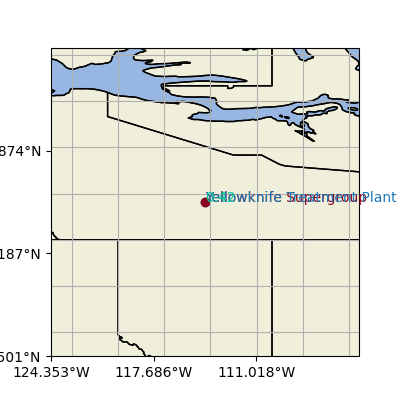

In [994]:
filtered_spatial_relationships = [sr for sr in spatial_relationships if sr.object_name in merged_strat_names_clean_with_informal.get(sr.doc_id, [])]

print(f"{len(filtered_spatial_relationships)=}")

filtered_questions = questions_from_spatial_relationships(spatial_relationships=filtered_spatial_relationships)
filtered_questions_with_distance = sorted([q for q in filtered_questions if q.distance_in_miles], key=lambda x: x.distance_in_miles)
print(f"{len(filtered_questions_with_distance)=}")

filtered_questions_with_distance_generator = (x for x in filtered_questions_with_distance)
filtered_questions_with_distance_counter = 0
HTML(next(filtered_questions_with_distance_generator).html_format())

filtered_questions_with_distance_counter=1



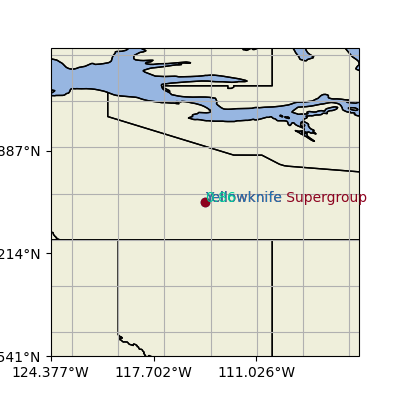

In [995]:
filtered_questions_with_distance_counter += 1
print(f"{filtered_questions_with_distance_counter=}")
HTML(next(filtered_questions_with_distance_generator).html_format())

In [319]:
# filtered questions indexes

strat_name_is_a_strat_name = [23, 24, 25, 28, 35, 36, 43, 56, 59, 60, 63, 66, 70, 72]
informal_strat_name_is_not_a_strat_name = [13, 37, 39, 40, 41, 44, 45, 47, 48, 51, 52, 53, 54, 64, 71]
strat_name_is_location_name = [14, 16, 17, 18, 19, 20, 22, 26, 27, 29, 30, 31, 33, 34, 46, 49, 50, 57, 58, 62, ]
strat_name_is_a_strat_name_and_something_else = [15, 65]
picked_wrong_strat_name = [61, ]
trash = [21, 38, 42, 55, 67, 68, 73, 74, 75, 76, 77, 78, 79, 80, ]  # <- trash frequency way up after > 500 mi

# need to specify in prompt
# valid stratnames at that point in the doc
# strat name and location name cannot overlap
# prompt should favor whole stratname if possibel - usually the informal is used i.e. Sevy instead of Sevy Dolomite, when Sevy Dolomote present in text

In [258]:
strat_name_is_a_strat_name = [23, 24, 25, 28, 35, 36, 43, 56, 59, 60, 63, 66, 70, 72]
len(strat_name_is_a_strat_name)

14

In [341]:
serialize_questions_to_json_by_index(
    questions=filtered_questions_with_distance, 
    output_path=Path("/Users/imcconnell/PycharmProjects/text2graph_llm/data/stratname_filtered_squad_question_keepers.json"), 
    indexes=strat_name_is_a_strat_name
)

INFO:root:The function 'find_all_occurrences' took 0.0050 seconds to execute.


[
  {
    "word": "Simonson Dolomite",
    "start": 4,
    "end": 21,
    "link": "https://macrostrat.org/api/defs/autocomplete?query=Simonson%20Dolomite"
  }
]



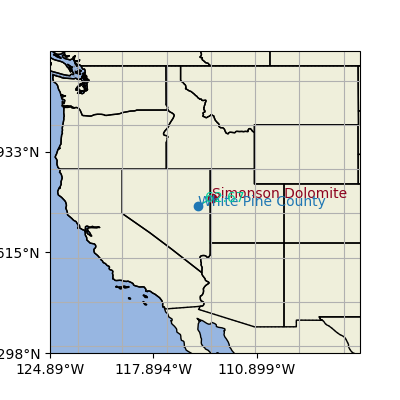

In [340]:
from text2graph.macrostrat import find_all_occurrences



n=23
print(json.dumps(find_all_occurrences(
    text=filtered_questions_with_distance[n].context,
    words=[filtered_questions_with_distance[n].object]
), indent=2))
HTML(filtered_questions_with_distance[n].html_format())



In [1]:
no_distance_filtered_questions = [q for q in filtered_questions if not q.distance_in_miles]
no_distance_filtered_questions_gen = (x for x in no_distance_filtered_questions)
no_distance_filtered_questions_counter = 0
HTML(next(no_distance_filtered_questions_gen).html_format())

NameError: name 'filtered_questions' is not defined

In [1634]:
no_distance_filtered_questions_counter += 1
print(f"{no_distance_filtered_questions_counter=}")
HTML(next(no_distance_filtered_questions_gen).html_format())

no_distance_filtered_questions_counter=624


In [1621]:
print(no_distance_filtered_questions[607].context)

5. A significant tonnage of kimberlite has already been identified at C29/30, however the mini-bulk sample appears to be inconclusive, given that it failed to replicate the diamond contents of the immediately adjacent NQ
Christopher, J.E., 2003: Jura-Cretaceous Success Formation and Lower Cretaceous Manville Group of Saskatchewan, Report 223, Sask. Industry and Resources.
Downie, I.F., 1995: A Review of Exploration in Summer, 1995 on the holdings of the Candle Lake Joint Venture by/for Kennecott Canada Inc.; Saskatchewan Industry and Resources Assessment File 73 H 15 – 0004R, 16 p.
Downie, I.F., 1996: Report of Exploration Winter, 1996 at Candle Lake for Kennecott Canada Inc.; Saskatchewan Industry and Resources Assessment File 73 – 0011R, 23p.


In [1636]:
can_get_the_actual_answers = [
    20, 21, 27, 29, 30, 35, 48, 75, 78, 79, 93, 147, 148, 149, 179, 192, 210, 211, 212, 213, 214, 215, 242, 265, 269, 274, 277,
    288, 307, 322, 331, 340, 342, 366, 381, 387, 404, 405, 406, 407, 408, 411, 447, 448, 457, 470, 480, 492, 508, 608, 609, 610
]
strat_name_ambiguous = [308, 335, 336, 341, 356, 368, 373, 375, 429, 475]
location_ambiguous = [262, 263, 279, 281, 378]
defined_location_but_not_geolocatable = [250, 252, 303, 314, 321, 328, 332, 333, 334, 339, 343, 362, 396, 409, 434, 442, 448, 495, 525, 540, 542, 608]
implied_location = [325]
direction_of_relationship_is_reversed = [71]
location_wrong = [330]
no_actual_stratname = [
    64, 65, 245, 247, 257, 259, 268, 289, 296, 300, 306, 310, 320, 344, 357, 358, 361, 371, 374, 379, 385, 388, 391, 394, 395, 398, 410, 415,
    416, 417, 421, 431, 432, 433, 450, 453, 460, 461, 467, 468, 514, 531, 
]
no_location = [
    248, 249, 256, 258, 278, 285, 287, 290, 292, 294, 301, 312, 321, 327, 345, 348, 355, 370, 376, 380, 382, 393, 397, 401, 402, 412, 413, 418, 
    422, 423, 424, 428, 436, 437, 439, 444, 445, 449, 451, 457, 458, 459, 472, 473
    
]
no_location_or_stratname = [273, 283, 286, 297, 298, 299, 302, 311, 316, 323, 324, 347, 349, 350, 353, 354, 360, 454, 462, 463, 474, ]
not_english = [346, 383, 384]

print(len(can_get_the_actual_answers))

52


In [1647]:
updated_hit_questions_to_add_to_keepers = []
good_qs_with_mods_gen = (x for i, x in enumerate(no_distance_filtered_questions) if i in can_get_the_actual_answers)

In [1847]:
# get next question
this_question = next(good_qs_with_mods_gen)
HTML(this_question.html_format())

StopIteration: 

In [1751]:
# good_question_list = [x for i, x in enumerate(no_distance_filtered_questions) if i in can_get_the_actual_answers]
# HTML(good_question_list[20].html_format())
# this_question = good_question_list[20]

In [1715]:
# print(this_question.context)

In [1845]:
# object is stratname
# subject is location
updated_q = new_question_from_old(
    question=this_question, 
    **dict(
        # object="Mural Limestone",
        # predicate="mineralized in the",
        subject="Marysvale Volcanic Field",
    )
)
HTML(updated_q.html_format())

INFO:root:The function 'find_all_occurrences' took 0.0001 seconds to execute.


In [1846]:
updated_hit_questions_to_add_to_keepers.append(updated_q)
print(f"{len(updated_hit_questions_to_add_to_keepers)=}")

len(updated_hit_questions_to_add_to_keepers)=55


In [1830]:
# # last added question
# HTML(updated_hit_questions_to_add_to_keepers[-1].html_format())

In [1848]:
# dump fixed questions to json
serialize_questions_to_json_by_index(
    questions=updated_hit_questions_to_add_to_keepers, 
    output_path=Path("/Users/imcconnell/PycharmProjects/text2graph_llm/data/no_distance_filtered_fixed_squad_question_keepers.json"), 
    indexes=range(len(updated_hit_questions_to_add_to_keepers))
)

In [255]:
# combine original keepers with modified to be keepers
orignals = Path("/Users/imcconnell/PycharmProjects/text2graph_llm/data/stratname_filtered_squad_question_keepers.json")
fixed = Path("/Users/imcconnell/PycharmProjects/text2graph_llm/data/no_distance_filtered_fixed_squad_question_keepers.json")
with open(orignals, 'r') as f:
    original_keepers = f.readlines()
with open(fixed, 'r') as f:
    fixed_keepers = f.readlines()

combined_keepers = original_keepers + fixed_keepers
combined_keepers_output = Path("/Users/imcconnell/PycharmProjects/text2graph_llm/data/combined_squad_question_keepers.json")
with open(combined_keepers_output, 'w') as f:
    f.writelines(combined_keepers)

In [256]:
len(combined_keepers)

66

# get no triplet questions i.e. only location, or only stratname


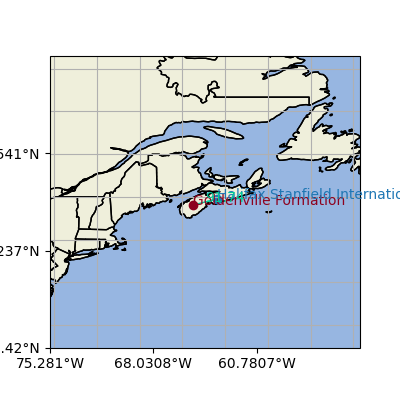

In [1861]:
question_for_context = SQuADStratPipelineQuestion(**json.loads(combined_keepers[3]))
HTML(question_for_context.html_format())
# json.loads(combined_keepers[1])a

In [1862]:
question_for_context.context

'5.3 INFRASTRUCTURE AND LOCAL RESOURCES, POWER, WATER, PERSONNEL, POTENTIAL TAILINGS STORAGE, WASTE DISPOSAL, HEAP LEACH PADS, PROCESSING PLANT SITES\nSherbrooke is a 5 minute drive from the project site and provides access to basic services such banking, gas/service stations, a grocery store, restaurants, accommodation and a hospital. Power, telephone service (landline and cellular), satellite TV, and high speed Internet service are available at the Goldenville site. More extensive services are available in the nearest larger urban centre of Antigonish, which is a University town ∼60 km to the north and serves as a substantial supply base for exploration and potential personnel needs. The Halifax Stanfield International Airport is 185 km from Goldenville via paved highways.'

# put all checked triplets in one file to push to be safe


In [259]:
# are two questions equal?
questions_files = [
    Path("/Users/imcconnell/PycharmProjects/text2graph_llm/data/squad_question_keepers.json"),
    Path("/Users/imcconnell/PycharmProjects/text2graph_llm/data/combined_squad_question_keepers.json"),
    Path("/Users/imcconnell/PycharmProjects/text2graph_llm/notebooks/data/negative_examples.json"),
]
all_json_lines = []
for qf in questions_files:
    with open(qf, 'r') as f:
        all_json_lines += f.readlines()

# serialize all_json_lines json file
with open("/Users/imcconnell/PycharmProjects/text2graph_llm/data/20240806_combined_test_triplets.json", 'w') as f:
    f.writelines(all_json_lines)




# jason strategy discussion
semantic similarity - clean 
in dynamic prompting
    alltextminiv6
    use clearn ectraetions here instead



verify with 4o to tune sensitivity


Rebuild weavite with sequence
    (minor chagnes in inject scipt)
